# Process data

Fetch data from geo-accession number GSE115978 for \url{https://www.cell.com/cell/fulltext/S0092-8674(18)31178-4}. 
3 files: 
* Cell annotation file
* Processed scRNAseq counts (from FASTQ files) 
* TPM 

## Basic data loading

In [33]:
from pathlib import Path
from urllib.request import urlretrieve

data_dir = Path("data/GSE115978")
data_dir.mkdir(parents=True, exist_ok=True)
base_url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE115nnn/GSE115978/suppl"

filenames = [
    "GSE115978_cell.annotations.csv.gz",
    "GSE115978_counts.csv.gz",
    "GSE115978_tpm.csv.gz", # TPM file is usually not needed and heavy, 
    # use it for bulk analysis only, but required for size effects in material
]

for filename in filenames:
    url = f"{base_url}/{filename}"
    output_path = data_dir / filename

    if output_path.exists():
        print(f"Already downloaded: {output_path}")
    else:
        print(f"Downloading {filename}...")
        urlretrieve(url, output_path)
        print(f"Saved to {output_path}")

Already downloaded: data/GSE115978/GSE115978_cell.annotations.csv.gz
Already downloaded: data/GSE115978/GSE115978_counts.csv.gz
Saved to data/GSE115978/GSE115978_tpm.csv.gz


In [36]:
import pandas as pd

annotations = pd.read_csv(data_dir / "GSE115978_cell.annotations.csv.gz", compression="gzip", index_col=0)
counts = pd.read_csv(data_dir / "GSE115978_counts.csv.gz", compression="gzip", index_col=0)
tpm = pd.read_csv(data_dir / "GSE115978_tpm.csv.gz", compression='gzip', index_col=0)
print("Annotations:", annotations.shape)
print("Counts:", counts.shape)
print("TPM:", tpm.shape)

Annotations: (7186, 6)
Counts: (23686, 7186)
TPM: (23686, 7186)


In [37]:
annotations.head()

,samples,cell.types,treatment.group,Cohort,no.of.genes,no.of.reads
cells,,,,,,
cy78_CD45_neg_1_B04_S496_comb,Mel78,Mal,post.treatment,Tirosh,8258,357919
cy79_p4_CD45_neg_PDL1_neg_E11_S1115_comb,Mel79,Mal,treatment.naive,Tirosh,2047,5727
CY88_5_B10_S694_comb,Mel88,Mal,post.treatment,Tirosh,5375,139218
cy79_p1_CD45_neg_PDL1_pos_AS_C1_R1_F07_S67_comb,Mel79,Mal,treatment.naive,Tirosh,5648,73996
cy78_CD45_neg_3_H06_S762_comb,Mel78,Mal,post.treatment,Tirosh,7409,380341


In [39]:
tpm.iloc[:5,:5]

,cy78_CD45_neg_1_B04_S496_comb,cy79_p4_CD45_neg_PDL1_neg_E11_S1115_comb,CY88_5_B10_S694_comb,cy79_p1_CD45_neg_PDL1_pos_AS_C1_R1_F07_S67_comb,cy78_CD45_neg_3_H06_S762_comb
C9orf152,0.000000,0.000000,0.000000,0.000000,0.000000
RPS11,8.144184,5.915091,7.243164,6.019502,7.974753
ELMO2,2.639232,0.000000,0.732052,3.687956,2.599318
CREB3L1,0.000000,0.000000,0.000000,0.000000,0.000000
PNMA1,3.656496,0.000000,0.536053,3.041418,4.132741


In [6]:
counts.iloc[:5,:5]

,cy78_CD45_neg_1_B04_S496_comb,cy79_p4_CD45_neg_PDL1_neg_E11_S1115_comb,CY88_5_B10_S694_comb,cy79_p1_CD45_neg_PDL1_pos_AS_C1_R1_F07_S67_comb,cy78_CD45_neg_3_H06_S762_comb
C9orf152,0,0,0,0,0
RPS11,370,1,75,15,345
ELMO2,43,0,2,18,43
CREB3L1,0,0,0,0,0
PNMA1,68,0,1,8,103


Paper computes average expression of a gene $i$ across a population of $N$ cell as $E_{i,p} = \log_2\big(1+\frac{\sum_{j=1}^N TPM_{i,j}}{N}\big)$

In [40]:
print("TPM-file minimum:", tpm.min().min())
print("TPM-file maximum:", tpm.max().max())
# TPM are already transformed. 

TPM-file minimum: 0.0
TPM-file maximum: 15.9229677186345


In [54]:
# Raw tpm 
import numpy as np
raw_tpm = 10 * np.expm1(tpm * np.log(2))

## Data cleaning as per paper

In [142]:
# Load metadata 
import pandas
cell_type_markers = pd.read_excel('data/mmc3.xlsx', header=1, sheet_name=0) # cell type markers 
DE_markers = pd.read_excel('data/mmc3.xlsx', header=1, sheet_name=1) # cell type markers 
cell_type_markers.head()

,ENDOTHELIAL CELL,STROMAL CELL,CAF,BASOPHILE,B CELL,EOSINOPHIL,ERYTHROCYTE,MAST CELL,MDSC,MEGAKAROCYTE,...,TH22,TREG,CYTOTOXIC CD8 T CELL,MACROPHAGE,CYTOTOXIC T CELL (SPECIFIC MARKERS),EXHAUSTED T CELL (SPECIFIC MARKERS),NAIVE T CELL (SPECIFIC MARKERS),TREG (SPECIFIC MARKERS),CELL CYCLE: G1/S,CELL CYCLE: G2/M
0,CD34,ICAM1,COL1A1,ANPEP,BLK,C3AR1,CD24,ENPP3,CCR7,CD9,...,AHR,CCR4,CCL3,CCR5,CCL3,CTLA4,CCR7,FOXP3,ATAD2,ANLN
1,CDH5,ICAM2,COL1A2,CCR3,CD19,C5AR1,GYPA,KIT,CD1A,GP1BA,...,CCR10,CD4,CCL4,CD14,CCL4,HAVCR2,LEF1,IL2RA,BLM,ANP32E
2,ENG,ICAM3,COL6A1,CD44,CD2,CCR1,PTPRC,NaN,CD1B,ITGA2B,...,CCR4,CNGB1,CD2,CD163,CST7,LAG3,SELL,NaN,BRIP1,AURKA
3,FLT4,ITGA4,COL6A2,CD63,CD22,CCR3,NaN,NaN,CD1C,ITGAV,...,CCR6,CTLA4,CD3D,CD33,GZMA,PDCD1,TCF7,NaN,CASP8AP2,AURKB
4,ICAM1,ITGB1,COL6A3,CD69,CD40,CD244,NaN,NaN,CD207,ITGB3,...,CD3D,ENTPD1,CD3E,CD68,GZMB,TIGIT,NaN,NaN,CCNE2,BIRC5


In [100]:
# Skip house keeping genes loading, not provided in the supplementary it seems.

In [57]:
# Create anndata object. 
import anndata as ad
from scipy.sparse import csr_matrix
adata = ad.AnnData(X=tpm.T, obs=annotations, var=pd.DataFrame(index=tpm.index))
adata.layers['counts'] = csr_matrix(counts.T)
adata.layers['tpm'] = raw_tpm.T

In [58]:
adata # cell by genes 

AnnData object with n_obs × n_vars = 7186 × 23686
    obs: 'samples', 'cell.types', 'treatment.group', 'Cohort', 'no.of.genes', 'no.of.reads'
    layers: 'counts', 'tpm'

In [110]:
adata.layers['counts'] = adata.X.copy() # store counts

In [73]:
# Filter cells with fewer than 1700 detected genes
detected = (counts.T > 0).sum(axis=1).ravel()
adata.obs['genes_detected_counts'] = detected
adata[adata.obs['genes_detected_counts']>= 1700]

/var/folders/r4/_v5hj9j14b53twvkrltmh9vh0000gn/T/ipykernel_35499/4293664841.py:2: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  detected = (counts.T > 0).sum(axis=1).ravel()


View of AnnData object with n_obs × n_vars = 7152 × 23686
    obs: 'samples', 'cell.types', 'treatment.group', 'Cohort', 'no.of.genes', 'no.of.reads', 'genes_detected_counts'
    layers: 'counts', 'tpm'

Average gene expression formula $E_{i} = \log_2\bigg(1+\frac{1}{N} \sum_{j=1}^N TPM_{ij}\bigg)$

In [113]:
# Filter cells where E < 4 via TPMs 
mean_tpm = np.mean(adata.layers['tpm'], axis=0)
adata.var['E_pop'] = np.log2(1+mean_tpm)

In [114]:
adata[adata.obs["genes_detected_counts"] >= 1700, adata.var["E_pop"] > 4]

View of AnnData object with n_obs × n_vars = 7152 × 6912
    obs: 'samples', 'cell.types', 'treatment.group', 'Cohort', 'no.of.genes', 'no.of.reads', 'genes_detected_counts', 'n_counts'
    var: 'exclude_genes', 'E_pop'
    uns: 'log1p'
    layers: 'counts', 'tpm'

In [115]:
adata.write_h5ad('data/processed_data.h5ad')


In [25]:
adata # .X contains normalized and log transformed data, .layers['counts'] contanis raw counts. 

AnnData object with n_obs × n_vars = 23686 × 7186
    var: 'samples', 'cell.types', 'treatment.group', 'Cohort', 'no.of.genes', 'no.of.reads'
    layers: 'counts'

In [173]:
adata.var.head()

,exclude_genes,E_pop,highly_variable,means,dispersions,dispersions_norm,highly_variable_nbatches,highly_variable_intersection
C9orf152,True,0.239309,False,0.005699,0.951474,-0.036870,0,False
RPS11,False,11.184727,False,2.129176,0.360610,0.308012,0,False
ELMO2,True,5.333367,False,0.572253,1.252787,0.618646,0,False
CREB3L1,True,0.619843,False,0.015797,0.924612,0.008461,0,False
PNMA1,True,4.939749,False,0.419950,1.313022,0.702429,0,False


In [174]:
adata.obs.head()

,samples,cell.types,treatment.group,Cohort,no.of.genes,no.of.reads,genes_detected_counts,n_counts
cells,,,,,,,,
cy78_CD45_neg_1_B04_S496_comb,Mel78,Mal,post.treatment,Tirosh,8258,357919,8094,16502.722649
cy79_p4_CD45_neg_PDL1_neg_E11_S1115_comb,Mel79,Mal,treatment.naive,Tirosh,2047,5727,2022,9107.532352
CY88_5_B10_S694_comb,Mel88,Mal,post.treatment,Tirosh,5375,139218,5141,11376.728902
cy79_p1_CD45_neg_PDL1_pos_AS_C1_R1_F07_S67_comb,Mel79,Mal,treatment.naive,Tirosh,5648,73996,5517,15255.667566
cy78_CD45_neg_3_H06_S762_comb,Mel78,Mal,post.treatment,Tirosh,7409,380341,7216,15722.633483


In [175]:
adata.X

array([[0.        , 1.76528437, 0.94371713, ..., 1.09136319, 0.93747669,
        0.        ],
       [0.        , 1.99794452, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.9807521 , 0.48949508, ..., 0.75533935, 1.11098187,
        0.        ],
       ...,
       [0.        , 2.17626413, 0.        , ..., 0.        , 1.51718019,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 1.78653814,
        0.        ],
       [0.        , 1.77630582, 1.98489253, ..., 0.        , 1.42150286,
        0.        ]])

## Quick plots for quality control

In [116]:
import scanpy as sc
sc.pp.highly_variable_genes(adata, n_top_genes=500, batch_key='Cohort')

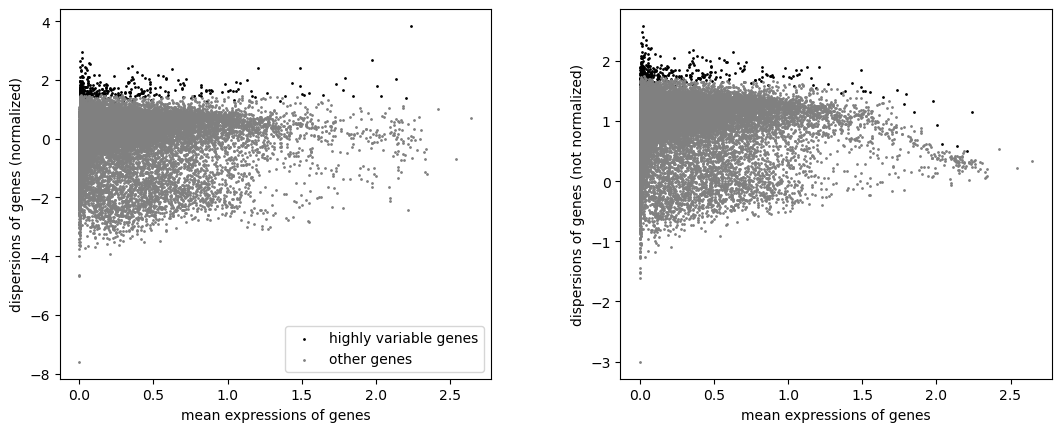

In [117]:
sc.pl.highly_variable_genes(adata)

In [123]:
adata.obs['cell.types'].unique()

['Mal', 'Macrophage', '?', 'Endo.', 'T.CD4', 'CAF', 'T.CD8', 'T.cell', 'NK', 'B.cell']
Categories (10, object): ['?', 'B.cell', 'CAF', 'Endo.', ..., 'NK', 'T.CD4', 'T.CD8', 'T.cell']

In [125]:
adata_mal = adata[adata.obs['cell.types']=='Mal'].copy() # Malignant data 
adata_im = adata[~(adata.obs['cell.types']=='Mal')].copy()  # Immune cells 

In [161]:
adata_im.write_h5ad('data/immune_cell_data.h5ad')
adata_mal.write_h5ad('data/mal_cell_data.h5ad')

### Immune cell data

Use the 194 biomarkers from Tirosh here. 

In [129]:
cell_type_markers.head()

Table S3A. Cell type signatures and markers used for cell classification; related to Figure 1.   \
                                                                                 ENDOTHELIAL CELL   
0                                               CD34                                                
1                                               CDH5                                                
2                                                ENG                                                
3                                               FLT4                                                
4                                              ICAM1                                                

                                                                          \
  STROMAL CELL     CAF BASOPHILE B CELL EOSINOPHIL ERYTHROCYTE MAST CELL   
0        ICAM1  COL1A1     ANPEP    BLK      C3AR1        CD24     ENPP3   
1        ICAM2  COL1A2      CCR3   CD19      C5AR1        GYPA       KIT   
2        ICAM3  COL6A1      CD44    CD2       CCR1       PTPRC       NaN   
3        ITGA4  COL6A2      CD63   CD22       CCR3         NaN       NaN   
4        ITGB1  COL6A3      CD69   CD40      CD244         NaN       NaN   

                       ...                                                 \
    MDSC MEGAKAROCYTE  ...   TH22    TREG CYTOTOXIC CD8 T CELL MACROPHAGE   
0   CCR7          CD9  ...    AHR    CCR4                 CCL3       CCR5   
1   CD1A        GP1BA  ...  CCR10     CD4                 CCL4       CD14   
2   CD1B       ITGA2B  ...   CCR4   CNGB1                  CD2      CD163   
3   CD1C        ITGAV  ...   CCR6   CTLA4                 CD3D       CD33   
4  CD207        ITGB3  ...   CD3D  ENTPD1                 CD3E       CD68   

                                                                           \
  CYTOTOXIC T CELL (SPECIFIC MARKERS) EXHAUSTED T CELL (SPECIFIC MARKERS)   
0                                CCL3                               CTLA4   
1                                CCL4                              HAVCR2   
2                                CST7                                LAG3   
3                                GZMA                               PDCD1   
4                                GZMB                               TIGIT   

                                                                            \
  NAIVE T CELL (SPECIFIC MARKERS) TREG (SPECIFIC MARKERS) CELL CYCLE: G1/S   
0                            CCR7                   FOXP3            ATAD2   
1                            LEF1                   IL2RA              BLM   
2                            SELL                     NaN            BRIP1   
3                            TCF7                     NaN         CASP8AP2   
4                             NaN                     NaN            CCNE2   

                    
  CELL CYCLE: G2/M  
0             ANLN  
1           ANP32E  
2            AURKA  
3            AURKB  
4            BIRC5  

[5 rows x 31 columns]

In [151]:
# PC restricted on 194 biomarkers should account for 50% variation
biomarkers194 = cell_type_markers.stack().dropna().astype(str).str.strip().unique()
print(len(adata.var_names.intersection(biomarkers194))) # could be explained by extra genes from house keeping genes not aggresively filtered out due to lack of file

321


In [155]:
adata_pca = adata_im[:, adata.var_names.intersection(biomarkers194)].copy()

In [157]:
sc.tl.pca(adata_pca)

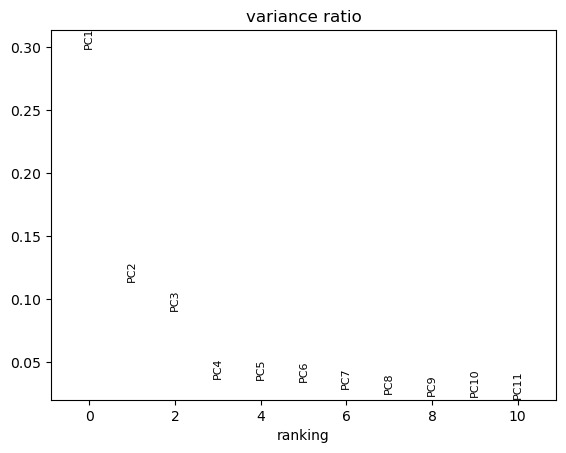

In [158]:
sc.pl.pca_variance_ratio(adata_pca, n_pcs=10)

In [160]:
variance_ratio = adata_pca.uns["pca"]["variance_ratio"]
cumulative_variance = np.cumsum(variance_ratio)
print(f"Variance explained by first 10 PCs: {100 * cumulative_variance[9]:.2f}%")

Variance explained by first 10 PCs: 70.83%


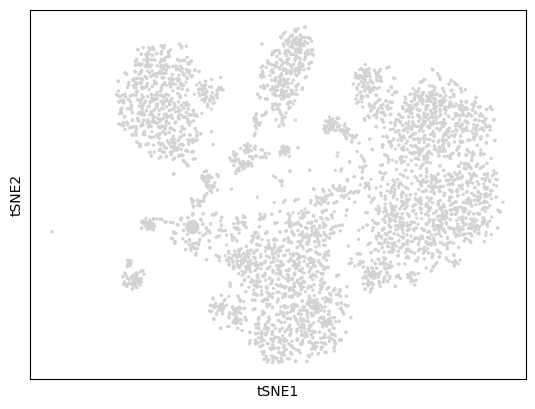

In [164]:
sc.tl.tsne(adata_pca)
sc.pl.tsne(adata_pca)

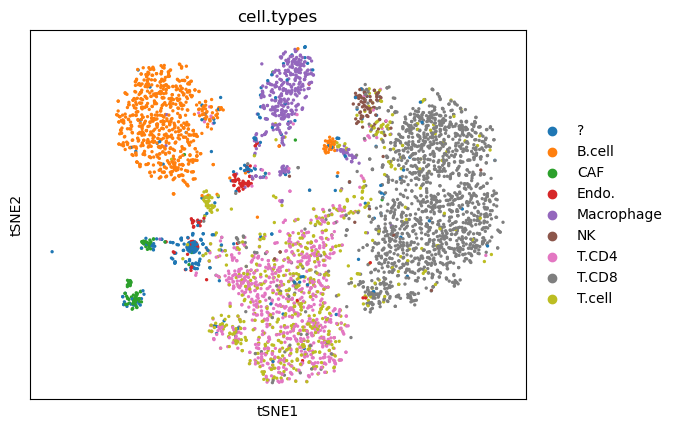

In [166]:
sc.pl.tsne(adata_pca, color='cell.types')

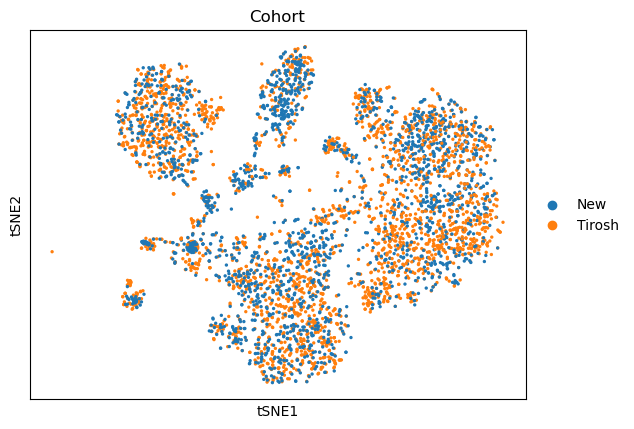

In [167]:
sc.pl.tsne(adata_pca, color='Cohort')

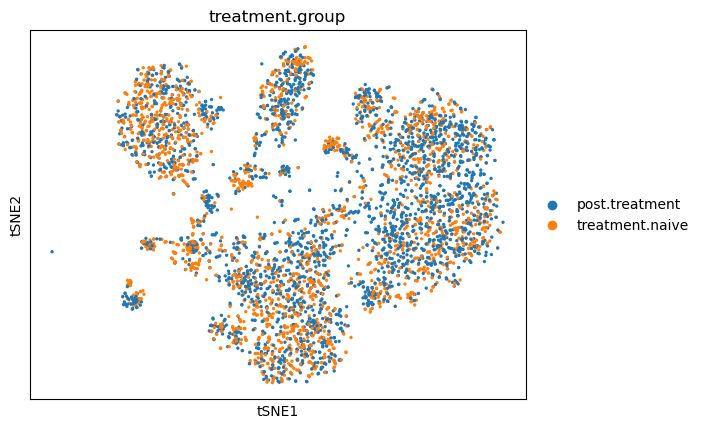

In [170]:
sc.pl.tsne(adata_pca, color='treatment.group')

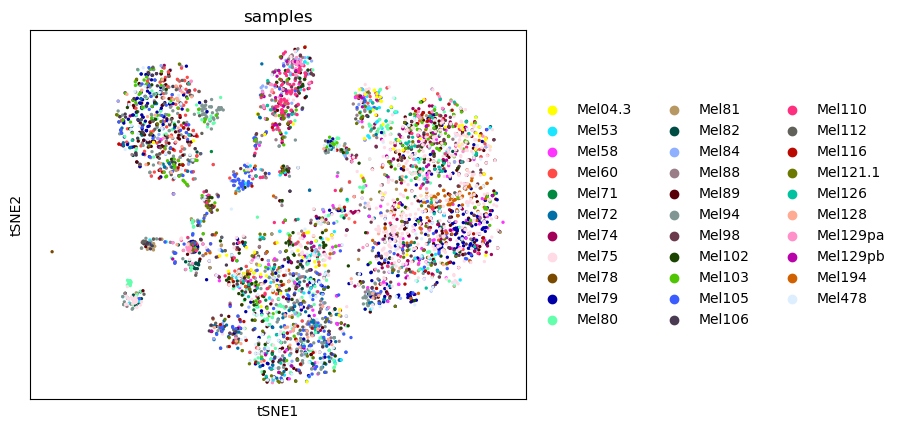

In [171]:
sc.pl.tsne(adata_pca, color='samples')